
# TP 14: Predicting dynamics with Neural-ODE

**The goal of this pratical is use machine learning models to predict the
evolution of dynamical systems driven by physical laws, *e.g.* ordinary
Differential Equations (ODE).**

Let us considers a physcial system in Newtonian mechanichs composed of a
**damped pendulum**, with length $l$ and mass $m$, and $\theta$ being the
angle with respect to the vertical direction:

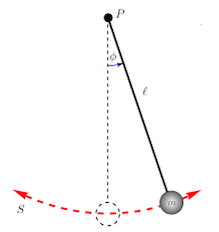

**Let us denote $\dot{\theta_t}:=\frac{d\theta}{dt}$ and
$\ddot{\theta}_t:=\frac{d^2\theta}{dt^2}$ as the first and second temporal
derivatives of $\theta$.** The dynamics of the pendulum is driven by the
following ODE on $\theta$:

\begin{equation} \ddot{\theta_t} + \omega_0^2~ sin\left(\theta_t\right) +
\alpha \dot{\theta}_t = 0 \end{equation}

where $\omega_0 = \sqrt{\frac{g}{\ell}}$ ($g$ is the gravitational constant, i.e. $9.8 ms^{-2}$), $\ell$ is the length of the rod,
and $\alpha = \frac{k}{ml^2}$ is the friction coefficient.

In the general case, the ODE does not have a closed-form
solution. Let us denote as $\mathbf{Y}_t=(\theta_t, \dot{\theta}_t)$ the 2d
state vector of the pendulum.



**<u>Question 1:</u> show that
 $\dot{\mathbf{Y}_t}=f\left({\mathbf{Y}_t}\right)$, *i.e* that the evolution
 of $\mathbf{Y}$ follows a first-order ODE. Give the expression of f.**


From a given initial condition $\mathbf{Y}_0=(\theta_0, \dot{\theta}_0)$, we
can estimate the state vector $\mathbf{Y}_t$ at any time $t$:

\begin{equation} \mathbf{Y}_t = \mathbf{Y}_0 + \int_0^t \dot{\mathbf{Y}_t} ~dt
= \mathbf{Y}_0 + \int_0^t f\left(\mathbf{Y}_t\right) dt
\end{equation}

where $f\left( \mathbf{Y}_t \right)$ only depends on the current state
$\mathbf{Y}_t$ at time $t$. The integral can be approximated
with numerical schemes. The Euler method is simplest one (see figure below):
starting from $\mathbf{Y}_0$, we have $\mathbf{Y}_{t+1} = \mathbf{Y}_{t} +
f\left(\mathbf{Y}_t\right)$ $\forall t>1$. The has been extensive studies for
developing improved numerical solvers in the last centuries, e.g. different
orders of Runge-Kutta solvers.

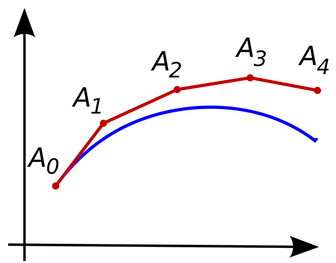


## Required Packages

Before starting, please ensure you have the following packages installed:

**Core packages:**
- `torch` (>=1.12) - PyTorch for deep learning
- `torchdiffeq` - ODE solvers for PyTorch (install with: `pip install torchdiffeq`)
- `scipy` - Scientific computing library (for `solve_ivp`)
- `numpy` - Numerical computing
- `matplotlib` - Plotting and visualization

**Installation commands:**
- **Conda:** `conda install pytorch scipy numpy matplotlib -c pytorch && pip install torchdiffeq`
- **Pip:** `pip install torch torchdiffeq scipy numpy matplotlib`

In [2]:
# For Google Colab users: Run this cell to install required packages
!pip install torch torchdiffeq scipy numpy matplotlib


## Part I. Generating damped pendulum simulations
First, lets do some import

In [3]:
import math
import os

# Fix OpenMP library conflict on macOS (common issue with PyTorch)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
from scipy.integrate import solve_ivp

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import optim

from torchdiffeq import odeint_adjoint, odeint  # odeint_adjoint used in commented line for students

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [20, 10]

# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
# Note: MPS can be unstable in some environments, use CPU if issues occur
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except Exception as e:
    # Fallback to CPU if device selection fails
    print(f"Warning: Device selection failed ({e}), using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [4]:

import os

if os.environ.get("TESTING_MODE", "off") == "ON":
    # Reduce parameters for faster testing
    num_seq = 5
    time_horizon = 10
    n_hidden = 50
    n_epochs = 10
    plt.show = lambda *args, **kwargs: None

### I.a) DampedPendulum

**We will write a DampedPendulum Dataset, which simulates different pendulum trajectories from differents initial conditions. Fill the code in the code in the following DampedPendulum class. We use the following setting:** $\omega_0= \frac{\Pi}{3}$, $\alpha= 0.2$ , with $dt=0.5$

You have to fill the `__init__` and `_compute_trajectory` functions. For `_compute_trajectory`, the goal is to simulate a given trajectory from an initial condition:
- The function `_get_initial_condition` is provided
- To perform the simulation in `_compute_trajectory`, you need to:
    - Call the `_get_initial_condition`
    - Call the solver: we will use the solve_ivp method from from `scipy.integrate`, using the 'DOP853' method (Explicit Runge-Kutta method of order 8).
- Since the simulation is computationally demanding, the class below uses a cache to store each trajectory

In [ ]:
class DampedPendulum(Dataset):
    def __init__(self, num_seq: int, time_horizon: int, dt: float):
        """Creates a new dataset of trajectories

        :param num_seq: Size of the dataset
        :param time_horizon: _description_
        :param dt: _description_
        """
        super().__init__()

        # ici c mon code
        self.omega0_square = (math.pi / 3) ** 2
        self.alpha = 0.2
        self.len = num_seq
        self.time_horizon = time_horizon

        # This caches the trajectories so we compute them once only
        self.data = [None] * num_seq

        self.t_eval = torch.arange(0, self.time_horizon, float(dt))

    def __getitem__(self, index: int):
        if self.data[index] is None:
            self.data[index] = torch.tensor(self._compute_trajectory(), dtype=torch.float32)
        return {"states": self.data[index], "t": self.t_eval}

    def __len__(self):
        return len(self.data)

    def _get_initial_condition(self):
        """Returns the vector of initial conditions"""
        y0 = np.random.randn(2) * 2.0 - 1
        r = np.random.rand() + 1.3
        y0 = y0 / np.sqrt((y0**2).sum()) * r

        return y0

    def _get__state_derivative(self, t, x):  # coords = [q,p].
        dq_dt = x[1]  # theta_dot
        dp_dt = -self.omega0_square * np.sin(x[0]) - self.alpha * x[1]  # theta_2dot
        return [dq_dt, dp_dt]

    def _compute_trajectory(self):
        y0 = self._get_initial_condition()
        t_eval_np = self.t_eval.numpy().astype(float)
        sol = solve_ivp(self._get__state_derivative,
                        [self.t_eval[0].item(), self.t_eval[-1].item()],
                        y0,
                        method='DOP853',
                        t_eval=t_eval_np)
        states = sol.y.T # je  veux avoir un shape de time_steps, dimensions
        return states


### I.b) Train/test data generation

**We can now define train and test dataloader** (use 25 train/test sequences
with a batch size of 25). **Plot the resulting trajectories ($\theta$ and
optionally $\dot{\theta}$).**

In [ ]:
# path = "./exp2/pendulum/pendulum"

# Default parameters (can be overridden by TESTING_MODE)
if 'num_seq' not in locals():
    num_seq = 25
if 'time_horizon' not in locals():
    time_horizon = 20
dt = 0.5
dataset_train = DampedPendulum(num_seq, time_horizon, dt)
dataset_test = DampedPendulum(num_seq, time_horizon, dt)


batch_size = 25

train_loader = DataLoader(
    dataset=dataset_train,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
    shuffle=True,
)
test_loader = DataLoader(
    dataset=dataset_test,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
    shuffle=False,
)

In [ ]:
# Show one item of the dataset

dataset_train[0]


{'states': tensor([[ 2.0246,  0.4845],
         [ 2.1397, -0.0108],
         [ 2.0214, -0.4604],
         [ 1.6783, -0.9133],
         [ 1.1125, -1.3344],
         [ 0.3778, -1.5541],
         [-0.3787, -1.3998],
         [-0.9700, -0.9359],
         [-1.2972, -0.3705],
         [-1.3449,  0.1731],
         [-1.1349,  0.6521],
         [-0.7133,  1.0064],
         [-0.1665,  1.1309],
         [ 0.3691,  0.9654],
         [ 0.7627,  0.5870],
         [ 0.9432,  0.1316],
         [ 0.8984, -0.3015],
         [ 0.6569, -0.6427],
         [ 0.2834, -0.8183],
         [-0.1254, -0.7789],
         [-0.4633, -0.5479],
         [-0.6556, -0.2122],
         [-0.6737,  0.1355],
         [-0.5302,  0.4226],
         [-0.2715,  0.5877],
         [ 0.0305,  0.5931],
         [ 0.2962,  0.4476],
         [ 0.4622,  0.2067],
         [ 0.4986, -0.0596],
         [ 0.4094, -0.2868],
         [ 0.2272, -0.4241],
         [ 0.0048, -0.4438],
         [-0.1976, -0.3485],
         [-0.3309, -0.1752],
    

torch.Size([25, 40, 2])


<Figure size 2000x1000 with 0 Axes>

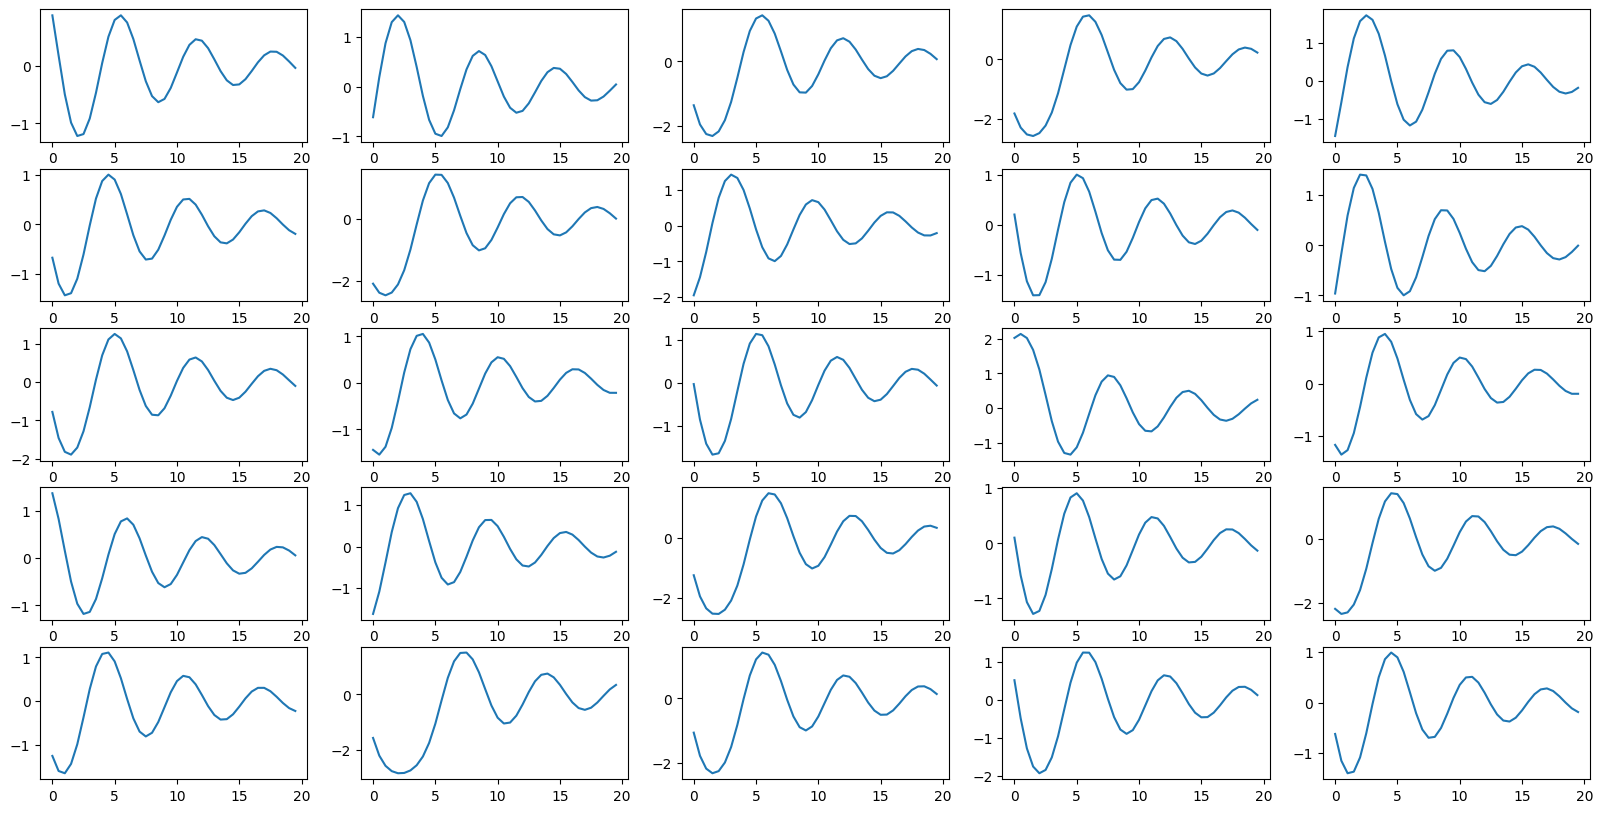

In [ ]:
data = next(iter(train_loader))
# je rappel aussi que: data["states"].shape = (batch_size, T, d) = ([25, 40, 2])
print(data["states"].shape)
draw_dottheta = False

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Determine grid size based on batch size
batch_size = data["states"].shape[0]
grid_size = min(int(np.ceil(np.sqrt(batch_size))), 5)
fig, axs = plt.subplots(grid_size, grid_size)

for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(data["t"][idx], data["states"][idx, :, 0])


if draw_dottheta:
    fig, axs = plt.subplots(grid_size, grid_size)
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            if idx < batch_size:
                axs[i, j].plot(data["t"][idx], data["states"][idx, 1, :])

<Figure size 2000x1000 with 0 Axes>

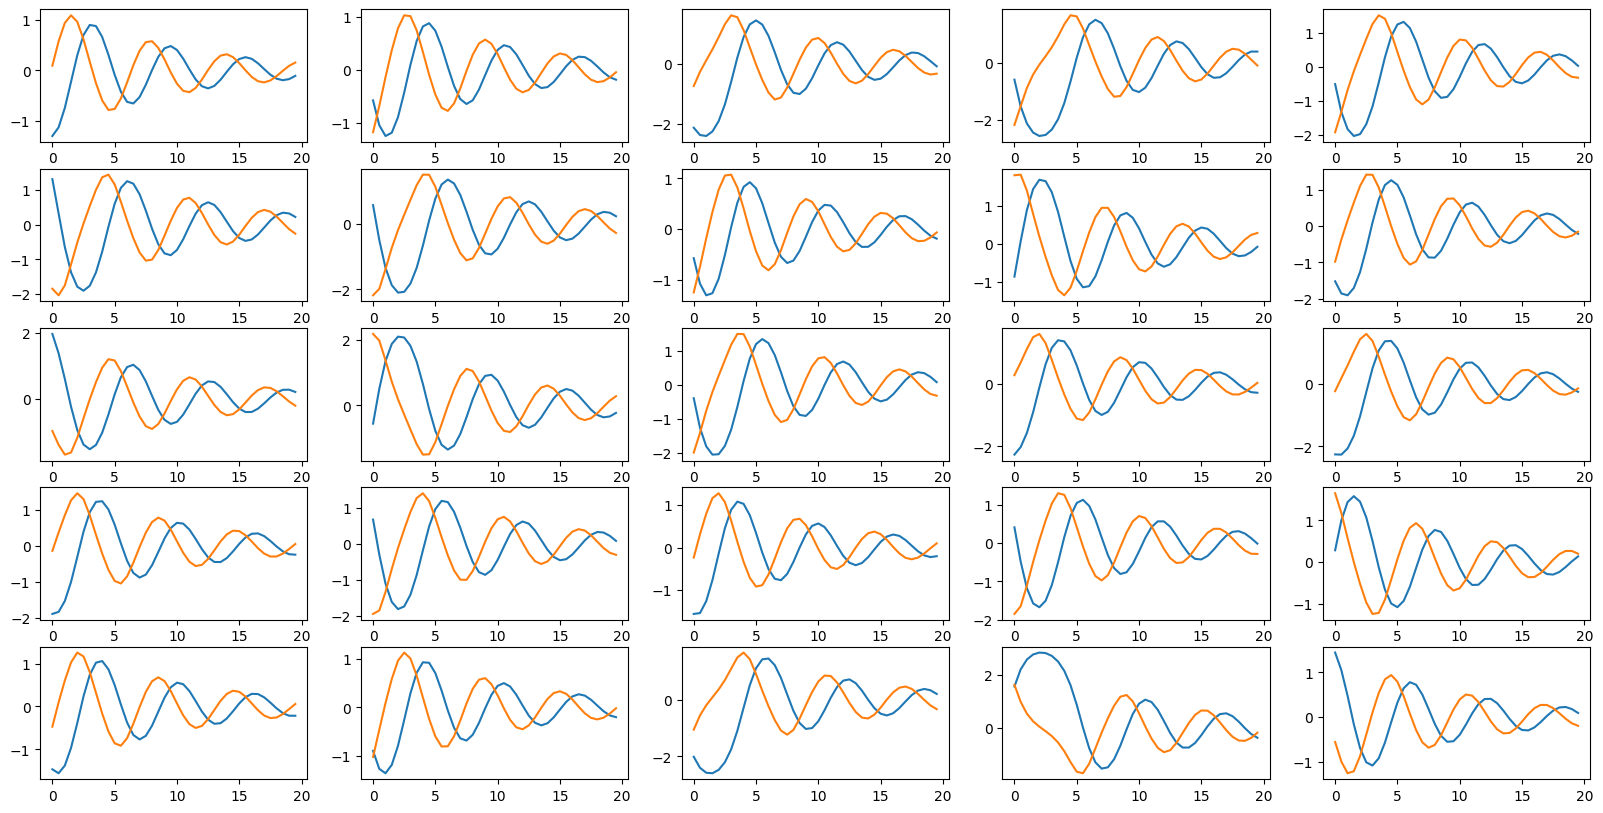

In [ ]:
data_test = next(iter(test_loader))

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Determine grid size based on batch size
batch_size_test = data_test["states"].shape[0]
grid_size_test = min(int(np.ceil(np.sqrt(batch_size_test))), 5)
fig, axs = plt.subplots(grid_size_test, grid_size_test)
draw_dottheta = True

for i in range(grid_size_test):
    for j in range(grid_size_test):
        idx = i * grid_size_test + j
        if idx < batch_size_test:
            axs[i, j].plot(data_test["t"][idx], data_test["states"][idx, :, 0])

if draw_dottheta:
    for i in range(grid_size_test):
        for j in range(grid_size_test):
            idx = i * grid_size_test + j
            if idx < batch_size_test:
                axs[i, j].plot(
                    data_test["t"][idx], data_test["states"][idx, :, 1]
                )




### Plot initial condition distribution

In [ ]:
print(data["states"].shape)
print(data_test["states"].shape)

torch.Size([25, 40, 2])
torch.Size([25, 40, 2])


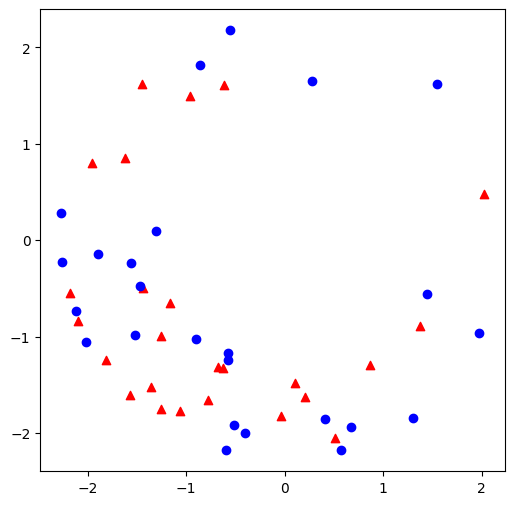

In [ ]:
theta0_train = data["states"][:, 0, 0]
dtheta0_train = data["states"][:, 0, 1]

theta0_test = data_test["states"][:, 0, 0]
dtheta0_test = data_test["states"][:, 0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(theta0_train, dtheta0_train,
            marker="^", c="red", label="Train")
plt.scatter(theta0_test, dtheta0_test,
            c="blue", label="Test")


## 2) Predicting trajectories with Neural-ODE

The goal is to use the Neural-ODE method [1] to predict the future trajectory
from an initial condition. **More precisely, the idea is to define a
parametric model, *e.g.* an neural network, to predict the state's derivative
from the current state value:
$\dot{\mathbf{Y}_t}=f_{\theta}\left({\mathbf{Y}_t}\right)$, with $\theta$
being the neural net parameters. From an initial condition $\mathbf{Y}_0$ and
$f_{\theta}\left({\mathbf{Y}_t}\right)$, we can then use Equation below to
predict the full predicted trajectory $\hat{\mathbf{Y}}$. The goal is to
optimize $\theta$ parameters such that predicted trajectories are close to the
GT trajectories in the training set.**

\begin{equation} \hat{\mathbf{Y}_t}  = \mathbf{Y}_0 + \int_0^t
f_{\theta}\left(\mathbf{Y}_t\right) dt \end{equation}


**Let's fill the DerivativeEstimator class to predict the the state's
derivative.** We will use a simple MLP (2 hidden layers + ReLU) for prediction
since the state is a 2D vector.


In [ ]:
class DerivativeEstimator(nn.Module):
    def __init__(self, n_state: int, n_hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_state, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_state)
        )

    def forward(self, t, state):
        return self.net(state)


**The forecaster will perform the prediction from a initial state $y_0$**. To
perform the numerical integration, we use the [`odeint` method from
torchdiffeq](https://github.com/rtqichen/torchdiffeq). We will use the generic
'rk4' solver to perform numerical integration. **Fill the following Forecaster
class with:**
- A constructor creating a reference to an DerivativeEstimator instance
- the forward method calls the `odeint` method to perform integration from an
  initial $y_0$ state. **N.B.**: the output dimensions after calling `odeint`
  will be `T x batch_size x n_c`, swap them to fit the requested Pytorch
  standard (`batch_size x n_c X T`)

In [ ]:
from torchdiffeq import odeint

class Forecaster(nn.Module):
    def __init__(self, n_state, n_hidden, method="rk4"):
        super().__init__()
        self.derivative_estimator = DerivativeEstimator(n_state, n_hidden)
        self.method = method

    def forward(self, y0: torch.Tensor, t: torch.Tensor):
        pred_y = odeint(
            self.derivative_estimator,
            y0,
            t,
            method=self.method
        )

        pred_y = pred_y.permute(1, 2, 0)
        return pred_y  # (B, N_c, T)



### Write the training loop!

For each batch:
- Get the first state of each training trajectory
- Perform prediction of the forecaster for each time step of the horizon
- We will use a simple MSE loss between the ground truth and predicted
  trajectories.
- Use an Adam optimizer (default paramters)
- Plot the train / test trajectories

In [ ]:
n_state = 2

if 'n_hidden' not in locals():
    n_hidden = 200
if 'n_epochs' not in locals():
    n_epochs = 1001

forecaster_net = Forecaster(n_state, n_hidden, method="rk4").to(device)

optimizer = optim.Adam(forecaster_net.parameters(), lr=1e-4)
traj_loss = nn.MSELoss()

from tqdm import tqdm

for e in tqdm(range(n_epochs)):
    epoch_loss = 0.0

    for data_batch in train_loader:
        optimizer.zero_grad()
        states = data_batch["states"].to(device)  # B x T x N_c
        t = data_batch["t"][0].to(device).float() # T (float!)

        y0 = states[:, 0, :]  # B x N_c
        pred_y = forecaster_net(y0, t)  # B x N_c x T
        gt_y = states.permute(0, 2, 1)
        loss = traj_loss(pred_y, gt_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if e % 100 == 0:
        print(f"Epoch {e}/{n_epochs}, Loss: {epoch_loss / len(train_loader):.6f}")


  0%|          | 1/1001 [00:00<03:53,  4.29it/s]

Epoch 0/1001, Loss: 2.364790


 10%|█         | 101/1001 [00:24<03:29,  4.30it/s]

Epoch 100/1001, Loss: 0.492291


 20%|██        | 201/1001 [00:49<03:06,  4.28it/s]

...

Epoch 800/1001, Loss: 0.004338


 90%|█████████ | 901/1001 [03:39<00:27,  3.63it/s]

Epoch 900/1001, Loss: 0.003230


100%|██████████| 1001/1001 [04:03<00:00,  4.11it/s]

Epoch 1000/1001, Loss: 0.002514


<Figure size 2000x1000 with 0 Axes>

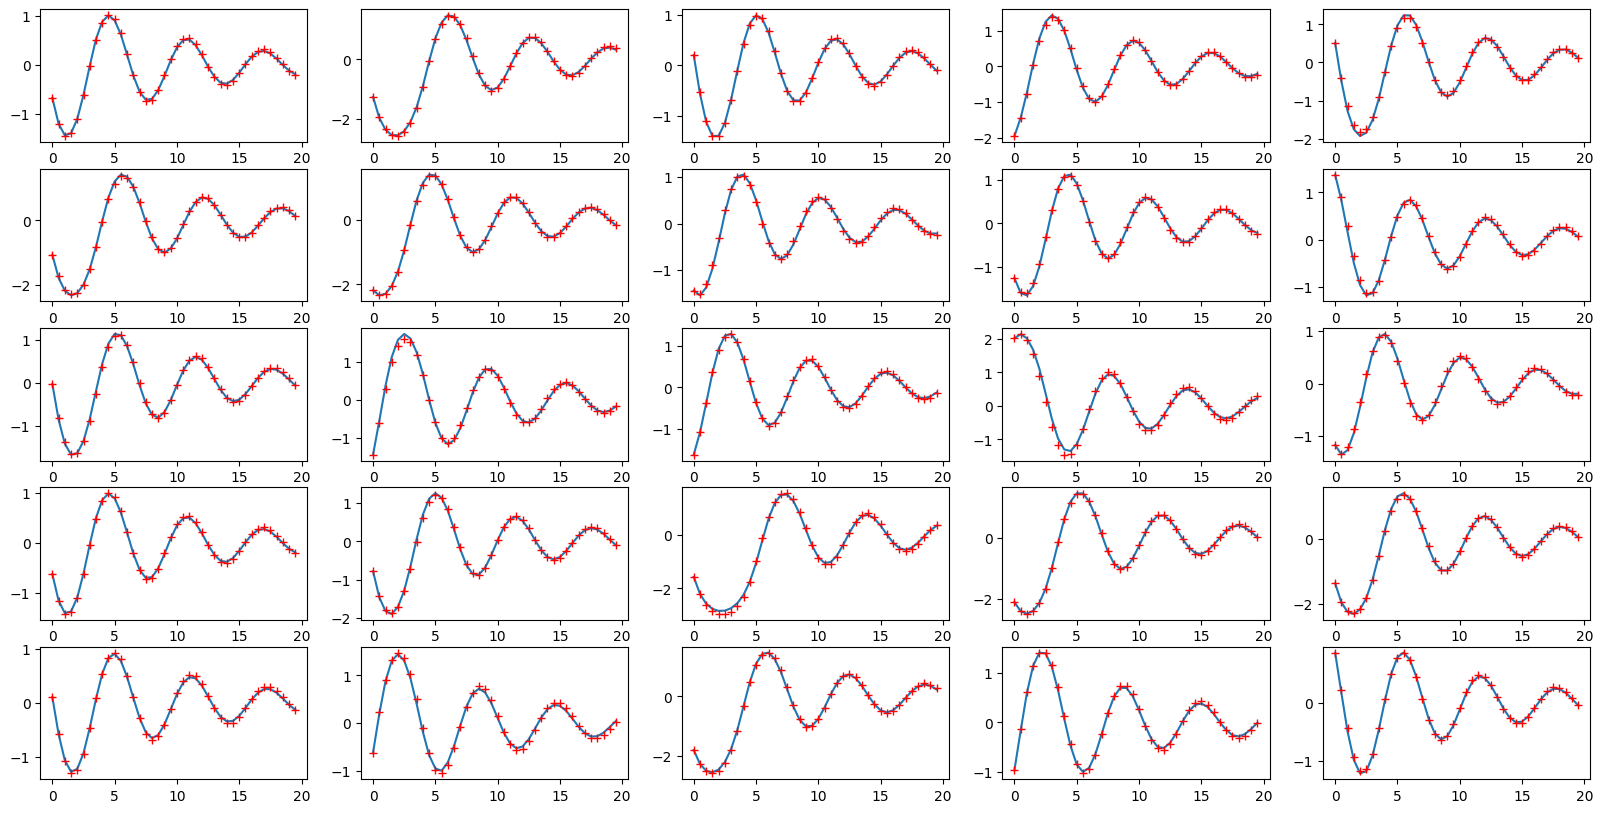

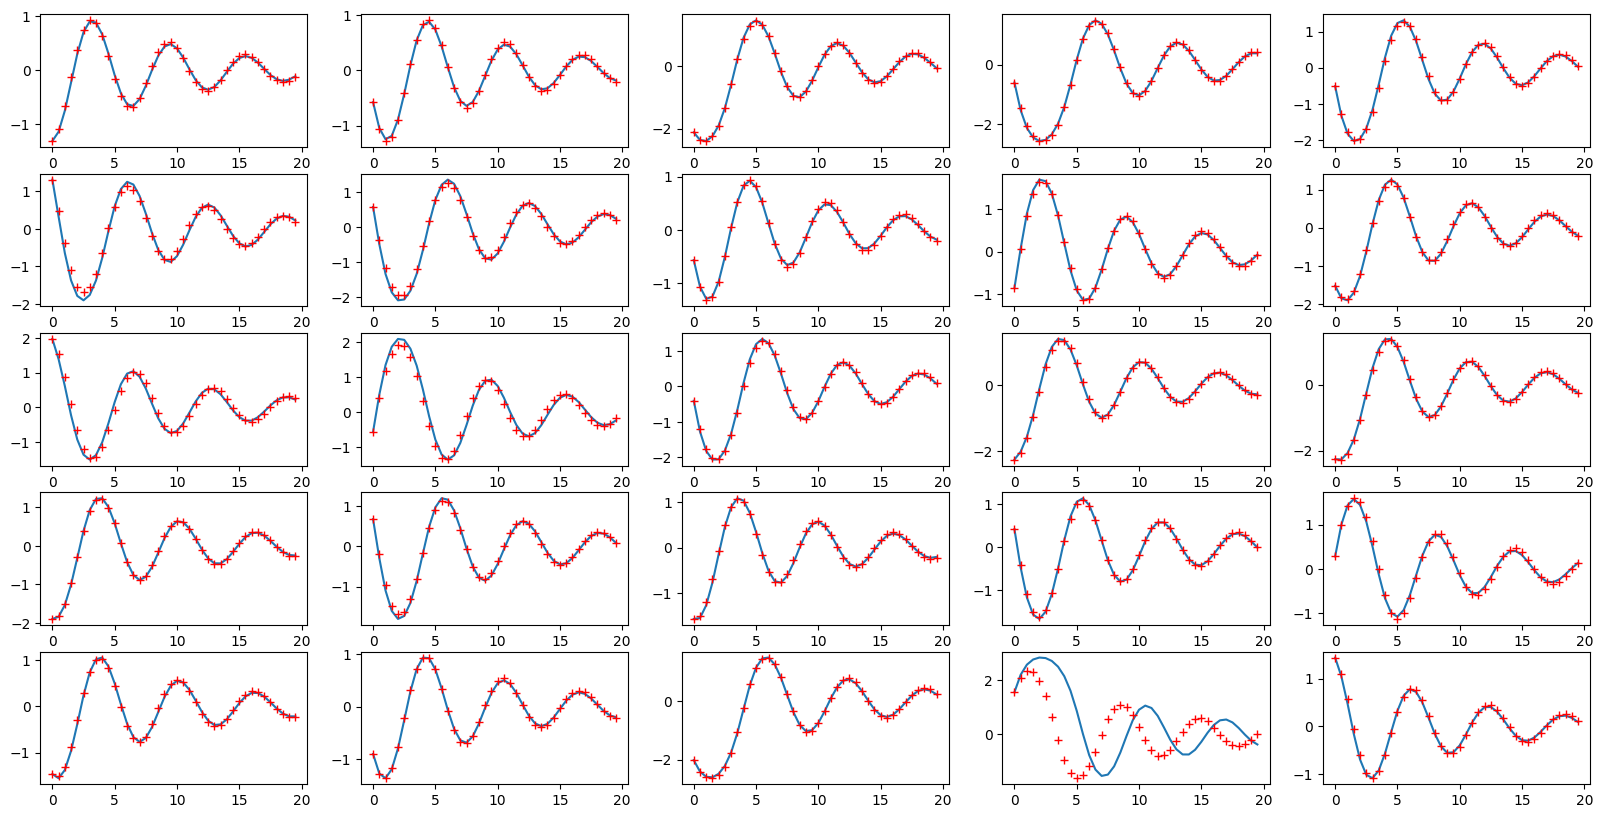

In [ ]:
# The code below plots the predicted values

## # pred contains
## pred = ...

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Get batch data for plotting (re-fetch if needed for device compatibility)
plot_batch = next(iter(train_loader))
plot_batch_test = next(iter(test_loader))

# Get predictions for plotting
with torch.no_grad():
    y0_plot = plot_batch["states"][:, 0, :].to(device) # Corrected: get initial state (all dimensions) for each batch
    t_plot = plot_batch["t"][0].to(device)
    pred_plot = forecaster_net(y0_plot, t_plot)

    y0_plot_test = plot_batch_test["states"][:, 0, :].to(device) # Corrected for test data as well
    t_plot_test = plot_batch_test["t"][0].to(device)
    pred_plot_test = forecaster_net(y0_plot_test, t_plot_test)

p = pred_plot.detach().cpu().numpy()
ptest = pred_plot_test.detach().cpu().numpy()

# Determine grid size based on batch size
batch_size = min(plot_batch["states"].shape[0], 25)
grid_size = int(np.ceil(np.sqrt(batch_size)))
if grid_size > 5:
    grid_size = 5

fig, axs = plt.subplots(grid_size, grid_size)
for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(
                plot_batch["t"][idx].cpu().numpy(),
                plot_batch["states"][idx, :, 0].cpu().numpy(), # Plot theta
                plot_batch["t"][idx].cpu().numpy(),
                p[idx, 0, :],
                "r+",
            )

fig, axs = plt.subplots(grid_size, grid_size)
for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(
                plot_batch_test["t"][idx].cpu().numpy(),
                plot_batch_test["states"][idx, :, 0].cpu().numpy(), # Plot theta
                plot_batch_test["t"][idx].cpu().numpy(),
                ptest[idx, 0, :],
                "r+",
            )



# Bonus: see [this paper](https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf) [1]
Experiment Neural ODE for other applications:
- **Replacing residual networks with ODEs for supervised learning** (see section 3 in paper), using the adjoint method.
- **Application for irregularly-sampled time series** (see section 5 in the paper).


[1] **Neural Ordinary Differential Equations.**
Ricky T. Q. Chen, Yulia Rubanova, Jesse Bettencourt, David K. Duvenaud.
NeurIPS 2018.

<!--bibtex

@inproceedings{nODE-NEURIPS2018,
 author = {Chen, Ricky T. Q. and Rubanova, Yulia and Bettencourt, Jesse and Duvenaud, David K},
 booktitle = {Advances in Neural Information Processing Systems},
 editor = {S. Bengio and H. Wallach and H. Larochelle and K. Grauman and N. Cesa-Bianchi and R. Garnett},
 pages = {},
 publisher = {Curran Associates, Inc.},
 title = {Neural Ordinary Differential Equations},
 url = {https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf},
 volume = {31},
 year = {2018}
}

... Other Bibtex entries go here.

-->

<!--bibtex

@inproceedings{nODE-NEURIPS2018,
 author = {Chen, Ricky T. Q. and Rubanova, Yulia and Bettencourt, Jesse and Duvenaud, David K},
 booktitle = {Advances in Neural Information Processing Systems},
 editor = {S. Bengio and H. Wallach and H. Larochelle and K. Grauman and N. Cesa-Bianchi and R. Garnett},
 pages = {},
 publisher = {Curran Associates, Inc.},
 title = {Neural Ordinary Differential Equations},
 url = {https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf},
 volume = {31},
 year = {2018}
}

... Other Bibtex entries go here.

-->

Neural ODE pour la classification

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint as odeint

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import time

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

class_names = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck"
]


In [11]:
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4467, 0.4398, 0.4066),
        std=(0.2603, 0.2566, 0.2713)
    )
])

transform_test = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4467, 0.4398, 0.4066),
        std=(0.2603, 0.2566, 0.2713)
    )
])

trainset = torchvision.datasets.STL10(
    root="./data", split="train", download=True, transform=transform_train
)
testset = torchvision.datasets.STL10(
    root="./data", split="test", download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



100%|██████████| 2.64G/2.64G [02:54<00:00, 15.1MB/s]


In [20]:
class ODEFunc(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        return self.net(x)


class ODEBlock(nn.Module):
    def __init__(self, odefunc, tol=1e-3):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0., 1.])
        self.tol = tol

    def forward(self, x):
        self.integration_time = self.integration_time.to(x)
        out = odeint(
            self.odefunc,
            x,
            self.integration_time,
            rtol=self.tol,
            atol=self.tol
        )
        return out[1]


class ODE_STL10(nn.Module):
    def __init__(self):
        super().__init__()

        self.downsampling = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.odefunc = ODEFunc(256)
        self.odeblock = ODEBlock(self.odefunc, tol=1e-3)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.downsampling(x)
        x = self.odeblock(x)
        x = self.classifier(x)
        return x


model = ODE_STL10().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100. * correct / total



In [21]:
train_losses = []
test_accuracies = []

epochs = 40

for epoch in tqdm(range(epochs)):
    start = time.time()

    loss = train_epoch(model, trainloader)
    acc = evaluate(model, testloader)

    train_losses.append(loss)
    test_accuracies.append(acc)
    scheduler.step()

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {loss:.4f} | "
        f"Test Acc: {acc:.2f}% | "
        f"Time: {time.time() - start:.1f}s"
    )



  2%|▎         | 1/40 [01:05<42:45, 65.77s/it]

Epoch 01 | Loss: 1.7404 | Test Acc: 30.51% | Time: 65.8s


  5%|▌         | 2/40 [02:12<42:08, 66.55s/it]

Epoch 02 | Loss: 1.5548 | Test Acc: 33.42% | Time: 67.1s


  8%|▊         | 3/40 [03:16<40:12, 65.20s/it]

...

Epoch 38 | Loss: 0.3821 | Test Acc: 63.88% | Time: 62.9s


 98%|█████████▊| 39/40 [39:27<01:02, 62.85s/it]

Epoch 39 | Loss: 0.3747 | Test Acc: 64.06% | Time: 63.1s


100%|██████████| 40/40 [40:30<00:00, 60.76s/it]

Epoch 40 | Loss: 0.3838 | Test Acc: 62.96% | Time: 63.1s


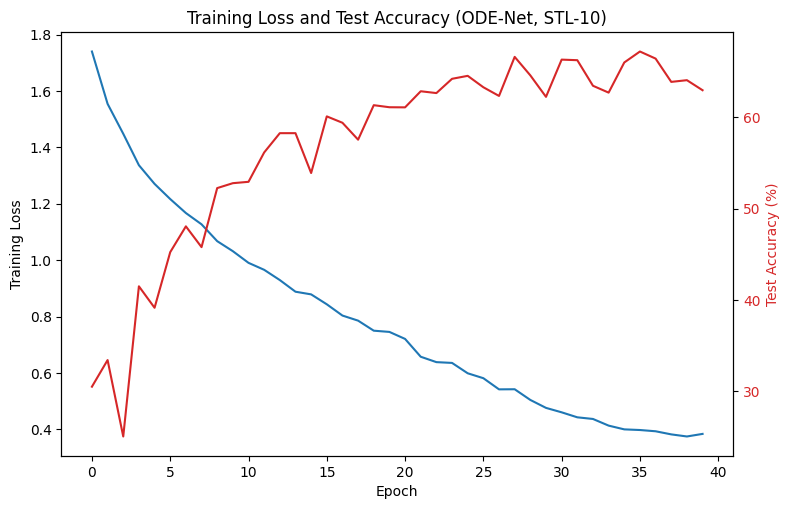

In [22]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.plot(train_losses, label="Train Loss")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.set_ylabel("Test Accuracy (%)", color="tab:red")
ax2.plot(test_accuracies, label="Test Accuracy", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.tight_layout()
plt.title("Training Loss and Test Accuracy (ODE-Net, STL-10)")
plt.show()

In [23]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in testloader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        y_true.append(y.cpu().numpy())
        y_pred.append(preds.cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

<Figure size 800x800 with 0 Axes>

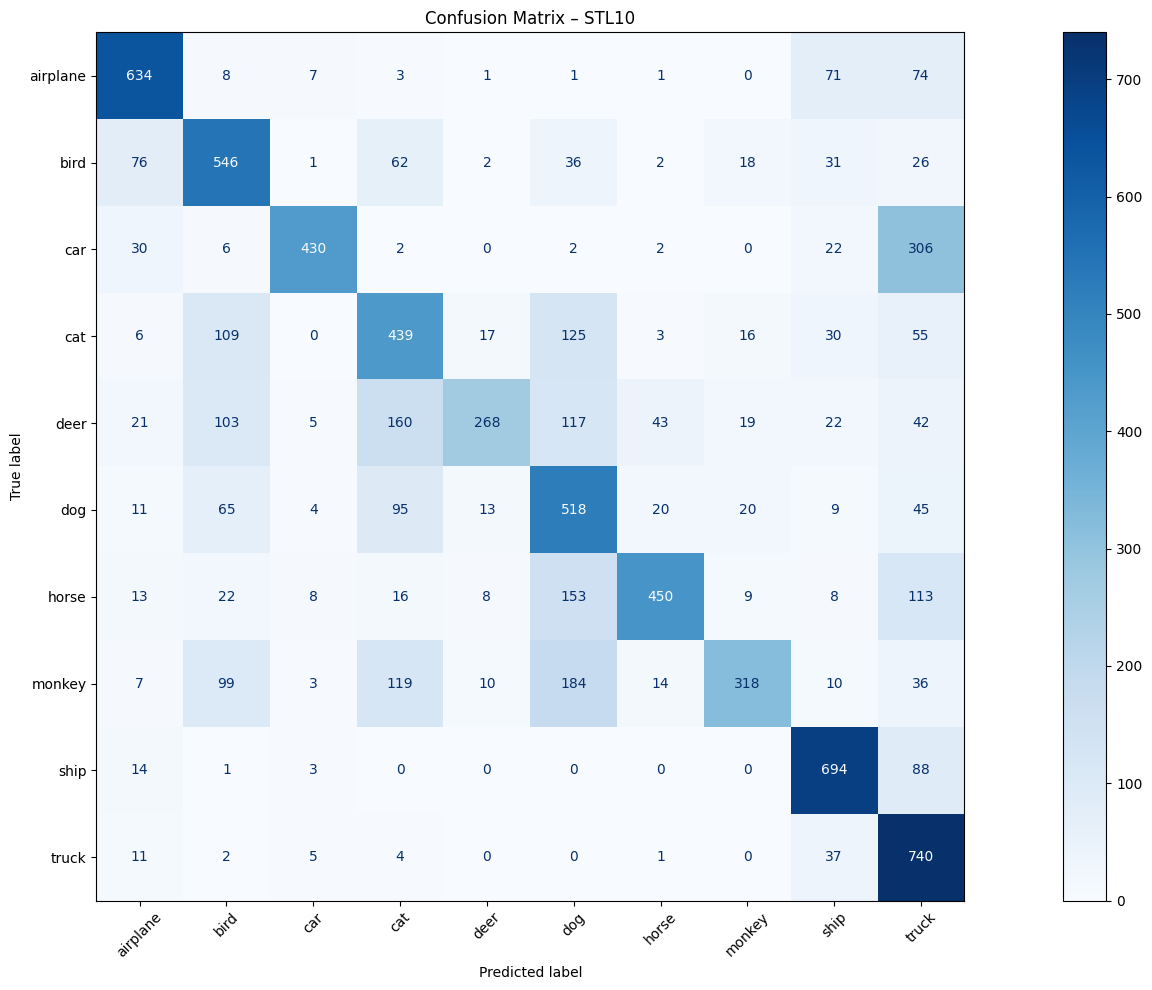

In [24]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)
plt.title("Confusion Matrix – STL10")
plt.tight_layout()
plt.show()


In [25]:
acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc:.4f}")
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)


Test accuracy: 0.6296
              precision    recall  f1-score   support

    airplane     0.7704    0.7925    0.7813       800
        bird     0.5682    0.6825    0.6201       800
         car     0.9227    0.5375    0.6793       800
         cat     0.4878    0.5487    0.5165       800
        deer     0.8401    0.3350    0.4790       800
         dog     0.4560    0.6475    0.5351       800
       horse     0.8396    0.5625    0.6737       800
      monkey     0.7950    0.3975    0.5300       800
        ship     0.7430    0.8675    0.8005       800
       truck     0.4852    0.9250    0.6366       800

    accuracy                         0.6296      8000
   macro avg     0.6908    0.6296    0.6252      8000
weighted avg     0.6908    0.6296    0.6252      8000



Latent Neural ODE pour séries temporelles irrégulières

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def true_dynamics(t, z):
    x, y = z[:, 0], z[:, 1]
    dx = -0.1 * x - y
    dy = x - 0.1 * y
    return torch.stack([dx, dy], dim=1)

t_full = torch.linspace(0, 25, 500).to(device)
z0 = torch.tensor([[1.0, 0.0]]).to(device)

with torch.no_grad():
    # Pass adjoint_params=() since true_dynamics is not an nn.Module and has no learnable parameters
    z_full = odeint(true_dynamics, z0, t_full)  # (T, 1, 2)

z_full = z_full.squeeze(1)

obs_idx = torch.linspace(0, 499, 30).long()
t_obs = t_full[obs_idx]
x_obs = z_full[obs_idx]

noise_std = 0.05
x_obs = x_obs + noise_std * torch.randn_like(x_obs)

# Batch dimension
x_obs = x_obs.unsqueeze(0)   # (1, T_obs, 2)

x_mean = x_obs.mean(dim=(0,1), keepdim=True)
x_std  = x_obs.std(dim=(0,1), keepdim=True) + 1e-6

x_obs = (x_obs - x_mean) / x_std

In [6]:
class Encoder(nn.Module):
    def __init__(self, obs_dim, latent_dim, hidden_dim=64):
        super().__init__()
        self.rnn = nn.GRU(obs_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.mu = nn.Linear(2 * hidden_dim, latent_dim)
        self.logvar = nn.Linear(2 * hidden_dim, latent_dim)

    def forward(self, x):
        _, h = self.rnn(x)
        h = torch.cat([h[0], h[1]], dim=1)
        return self.mu(h), self.logvar(h)

class LatentODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, t, z):
        t_vec = torch.ones(z.size(0), 1, device=z.device) * t
        return self.net(torch.cat([z, t_vec], dim=1))

class Decoder(nn.Module):
    def __init__(self, latent_dim, obs_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, obs_dim)
        )

    def forward(self, z):
        return self.net(z)

class LatentODE(nn.Module):
    def __init__(self, obs_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(obs_dim, latent_dim)
        self.odefunc = LatentODEFunc(latent_dim)
        self.decoder = Decoder(latent_dim, obs_dim)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, t):
        mu, logvar = self.encoder(x)
        z0 = self.reparam(mu, logvar)
        zt = odeint(self.odefunc, z0, t)
        zt = zt.permute(1, 0, 2)
        x_hat = self.decoder(zt)
        return x_hat, mu, logvar

def loss_fn(x, x_hat, mu, logvar, kl_weight):
    recon = ((x - x_hat) ** 2).mean()
    kl = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
    kl = torch.clamp(kl, min=0.1)
    loss = recon + kl_weight * max(kl, 0.1)
    return loss, recon, kl


In [7]:
latent_dim = 8
model = LatentODE(obs_dim=2, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 1500
kl_warmup = 300

from tqdm import tqdm

for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    kl_weight = min(1.0, epoch / kl_warmup)

    x_hat, mu, logvar = model(x_obs, t_obs)
    loss, recon, kl = loss_fn(x_obs, x_hat, mu, logvar, kl_weight)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if epoch % 100 == 0:
        print(f"[{epoch}] loss={loss:.4f} recon={recon:.4f} kl={kl:.4f}")
        with torch.no_grad():
          mu, _ = model.encoder(x_obs)     # z₀ moyen
          dz = model.odefunc(t_obs[0], mu) # champ de vecteurs en z₀
          print(f"||f(z)|| = {dz.norm(dim=1).mean().item():.4f}")

  0%|          | 1/1500 [00:01<46:06,  1.85s/it]

[0] loss=0.9626 recon=0.9626 kl=0.1000
||f(z)|| = 0.2753


  7%|▋         | 101/1500 [00:36<10:23,  2.24it/s]

[100] loss=0.8618 recon=0.7965 kl=0.1962
||f(z)|| = 2.3943


 13%|█▎        | 201/1500 [01:43<20:55,  1.03it/s]

...

 87%|████████▋ | 1301/1500 [24:16<04:07,  1.25s/it]

[1300] loss=0.1261 recon=0.0256 kl=0.1004
||f(z)|| = 4.6882


 93%|█████████▎| 1401/1500 [26:20<02:00,  1.21s/it]

[1400] loss=0.2115 recon=0.1115 kl=0.1000
||f(z)|| = 4.8808


100%|██████████| 1500/1500 [28:27<00:00,  1.14s/it]


In [8]:
t_plot = torch.linspace(0, 40, 600).to(device)

model.eval()
with torch.no_grad():
    mu, _ = model.encoder(x_obs)
    zt = odeint(model.odefunc, mu, t_plot)
    zt = zt.permute(1,0,2)
    x_pred = model.decoder(zt)

# dénormalisation
x_pred = x_pred * x_std + x_mean


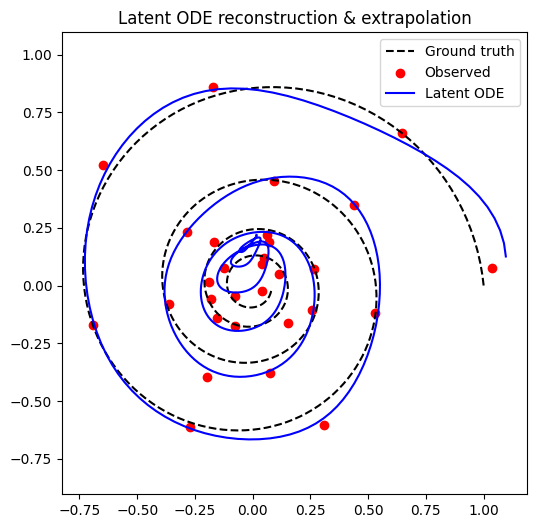

In [9]:
plt.figure(figsize=(6,6))
plt.plot(z_full[:,0].cpu(), z_full[:,1].cpu(), 'k--', label="Ground truth")
plt.scatter(x_obs[0,:,0].cpu()*x_std[0,0,0].cpu() + x_mean[0,0,0].cpu(),
            x_obs[0,:,1].cpu()*x_std[0,0,1].cpu() + x_mean[0,0,1].cpu(),
            c='r', label="Observed")
plt.plot(x_pred[0,:,0].cpu(), x_pred[0,:,1].cpu(), 'b', label="Latent ODE")
plt.legend()
plt.axis("equal")
plt.title("Latent ODE reconstruction & extrapolation")
plt.show()